In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gurobipy import *
import gurobipy as gp
from gurobipy import GRB
sns.set(style ="whitegrid", font_scale=1.5)
from matplotlib.ticker import MultipleLocator
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
custom_colors = ["#c45161", "#e094a0", "#f2b6c0", "#f2dde1", "#cbc7d8", "#8db7d2", "#5e62a9", "#434279"]
cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_colors)
color_palette = np.array(["#c45161", "#e094a0", "#f2b6c0", "#f2dde1", "#cbc7d8", "#8db7d2", "#5e62a9", "#434279"])
color = ['#93003a', '#00429d', '#93c4d2', '#6ebf7c']
matplotlib.rcParams.update({'legend.fontsize': 14, 'legend.handlelength': 2})
from tqdm import tqdm
import sys
import os
import pickle
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
import importlib
import re
from geopy.distance import geodesic

### Prepare input

#### Load `uam_system_model` dependencies

In [2]:
from uam_system_model.StarNetwork import StarNetwork
from uam_system_model.utils.visualize import plot_parameters, plot_travel_time

#### Prepare input

In [3]:
def calculate_distances_in_meters(coords):
    num_points = len(coords)
    distance_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        for j in range(num_points):
            if i != j:
                distance_matrix[i][j] = geodesic(coords[i], coords[j]).meters / 1600
    return distance_matrix

coordinates = np.array(
    [
        (33.94417072663332, -118.40248449470265),
        (34.043119432990345, -118.26720629762752),
        (33.81606030845284, -118.15122129260827),
        (34.17160155814583, -118.60525790222589),
        (34.13843197335217, -118.35511311047983),
        (33.812102161009804, -117.91897753216998),
        (34.09174681098575, -118.32725521957076),
        (34.08807589928915, -118.55063573741867),
        (34.06666969690935, -118.4114352069469),
    ]
)

distance_matrix = calculate_distances_in_meters(coordinates)
vertiports = ["LAX", "DTLA", "LGB", "WDHL", "UVS", "ANH", "HWD", "PSD", "BVH"]

vertiport_pmf = np.array([0, 6.1, 3.3, 1.5, 1.5, 5.4, 4.3, 2.5, 2.2])

# vertiport_pmf = np.array([0, 3.8, 2.4, 1, 1, 4.1, 2.5, 2.2, 1.5])

vertiport_pmf = vertiport_pmf / vertiport_pmf.sum()

flight_time_matrix = np.load("../UAM-System-Model/uam_system_model/data/config/flight_time_matrix.npy")
energy_consumption_matrix = np.load(
    "../UAM-System-Model/uam_system_model/data/config/energy_consumption_matrix.npy"
)

#### Create instance variable

In [4]:
network = StarNetwork(
    vertiport_names=vertiports,
    flight_distance_matrix=distance_matrix,
    flight_time_matrix=flight_time_matrix,
    energy_consumption_matrix=energy_consumption_matrix,
)

#### Load demand & visualize

In [11]:
SURVEY_P_TNC = 0.33327  # from the recorded data

total_seat = network.demand_generator.yearly_capacity[0] + network.demand_generator.yearly_capacity[1]
OD_PAX_TO_SEAT_RATIO = 77500000 / total_seat # from the recorded data

VERTIPORT_PMF = np.array([0, 3.8, 2.4, 1, 1, 4.1, 2.5, 2.2, 1.5])/ 100 # from passenger origin survey data

# 生成9*1的p_uam_array，使其和为1
p_uam_base = np.array([0.05, 0.15, 0.12, 0.08, 0.08, 0.18, 0.14, 0.11, 0.09])
p_uam_array = p_uam_base * SURVEY_P_TNC * OD_PAX_TO_SEAT_RATIO

vertiport_density = np.zeros((len(VERTIPORT_PMF), len(VERTIPORT_PMF)))
vertiport_density[0, :] = VERTIPORT_PMF
vertiport_density[:, 0] = VERTIPORT_PMF
p_uam_array = p_uam_array[:, None, None] * (np.repeat(vertiport_density[:, :, np.newaxis], 24, axis=2))

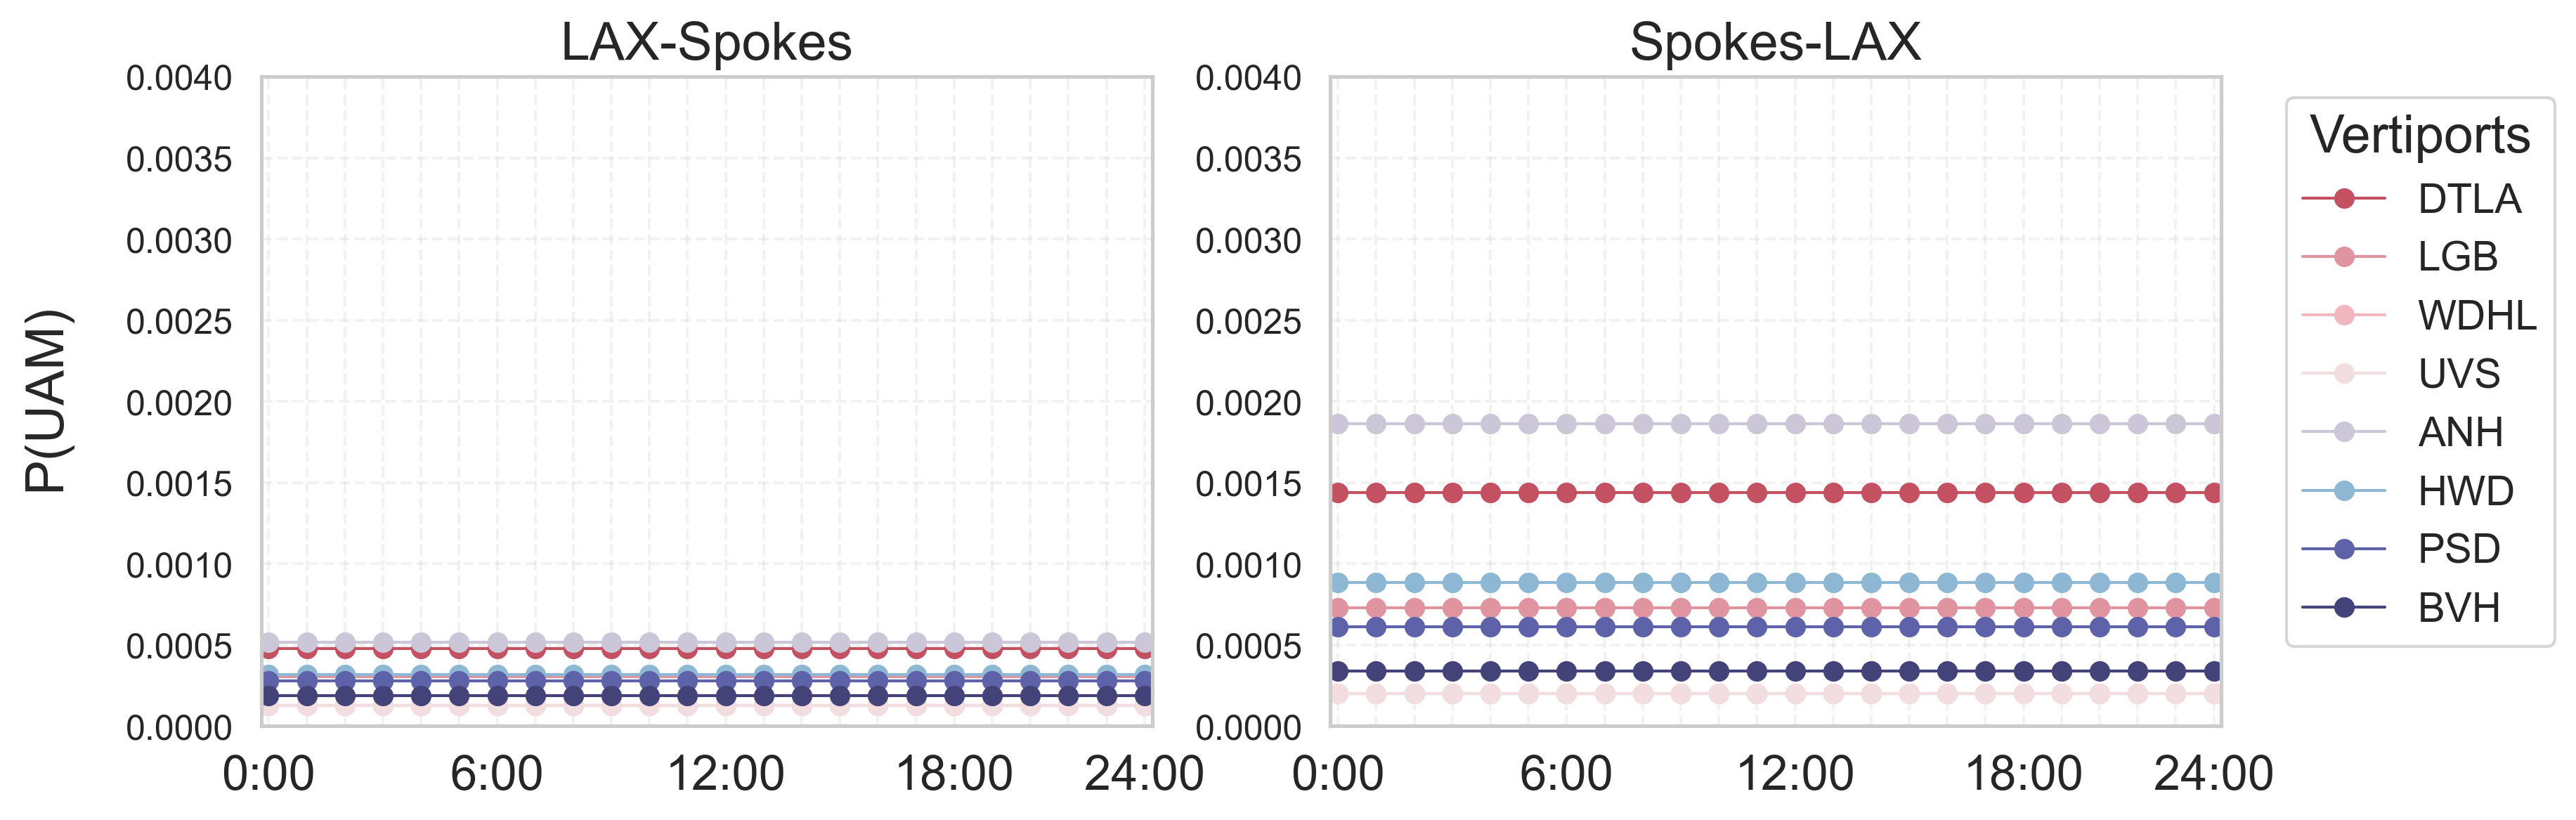

In [12]:
fig, ax = plot_travel_time(p_uam_array, vertiports, ylim=(0, 0.004), ylabel=r"")
for i in range(2):
    ax[i].tick_params(axis='y', labelsize=12)
fig.text(
    0.04, 0.5, "P(UAM)", ha="center", va="center", rotation="vertical"
);

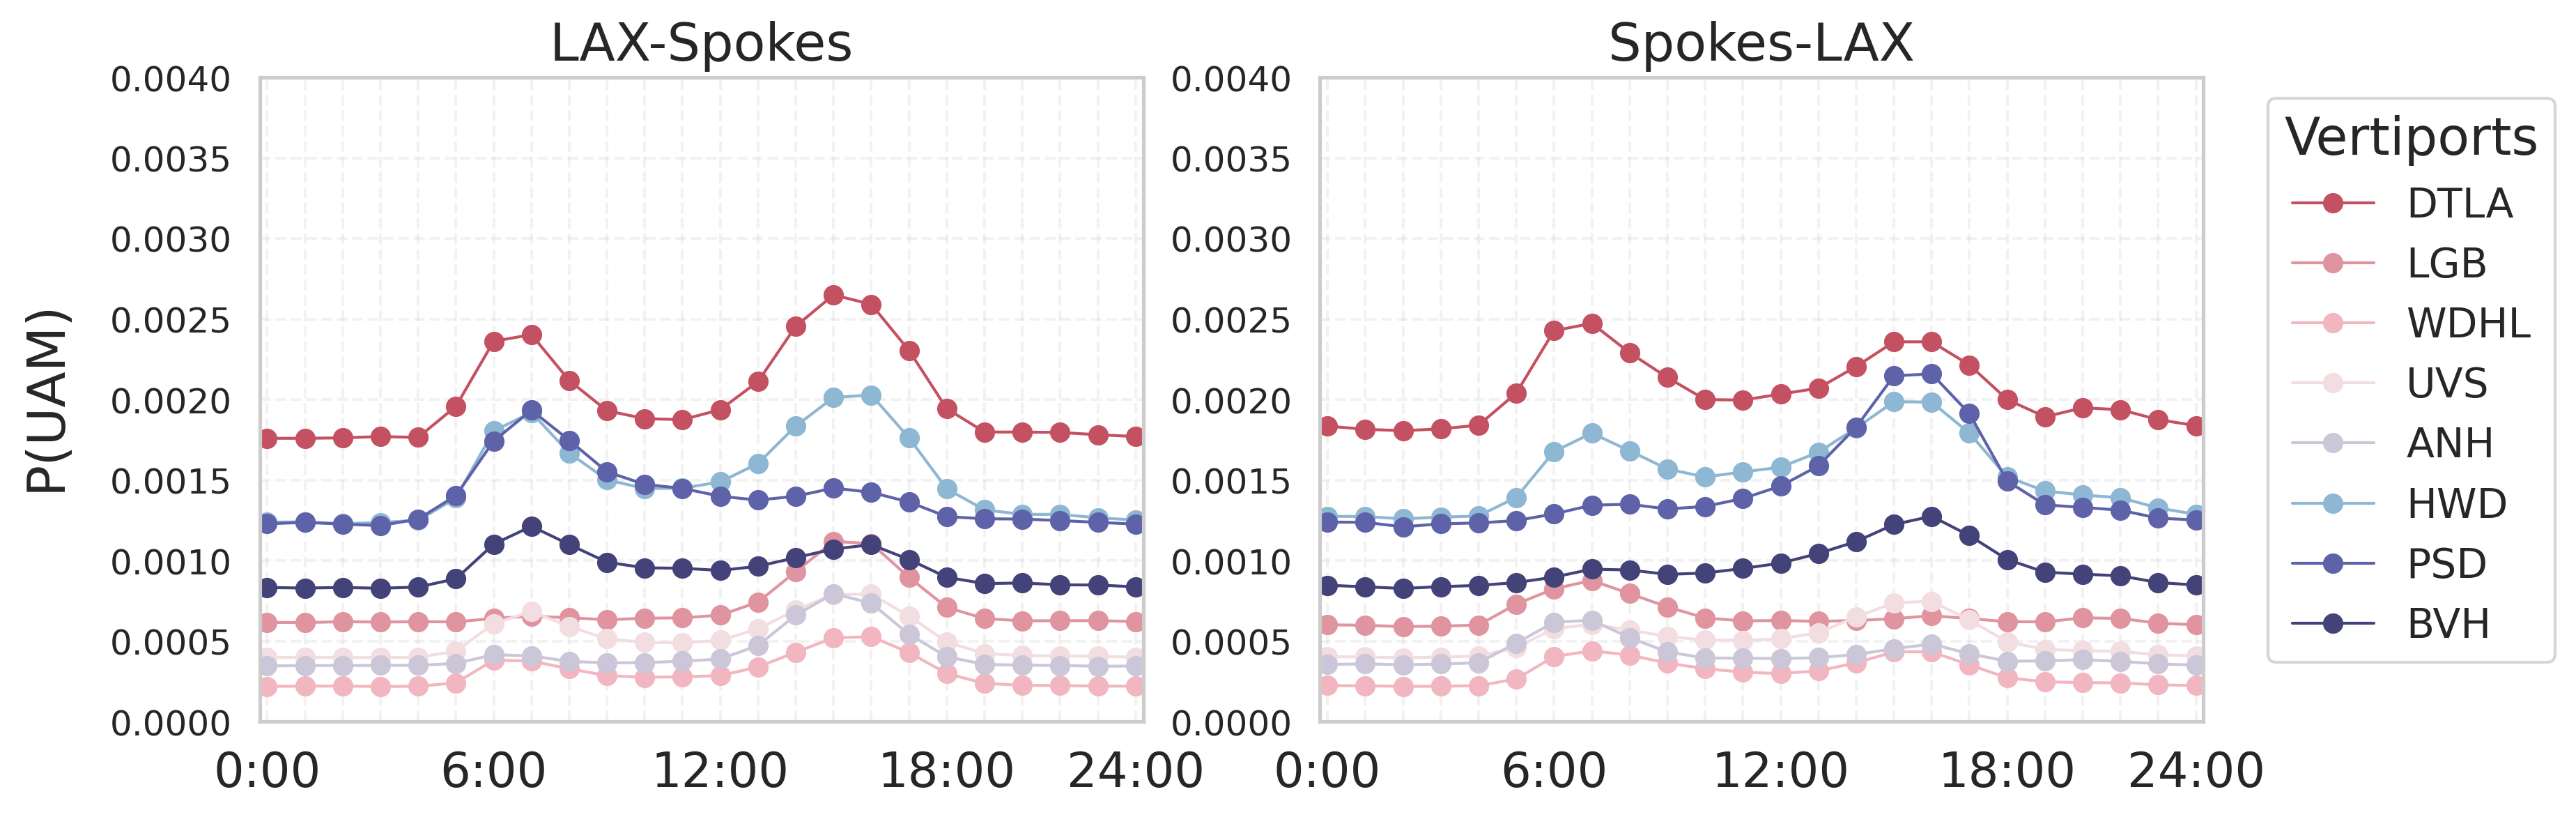

In [ ]:
# fig, ax = plot_travel_time(p_uam_array, vertiports, ylim=(0, 0.004), ylabel=r"")
# for i in range(2):
#     ax[i].tick_params(axis='y', labelsize=12)
# fig.text(
#     0.04, 0.5, "P(UAM)", ha="center", va="center", rotation="vertical"
# );

In [13]:
p_uam_array = np.concatenate([[p_uam_array[0,:,:] , p_uam_array[:,0,:]]])
network.load_demand(
    month=9,
    day=5,
    vertiport_pmf=p_uam_array,
    max_waiting_time=10,
    auto_regressive_alpha=0.7,
    seed=9,
)

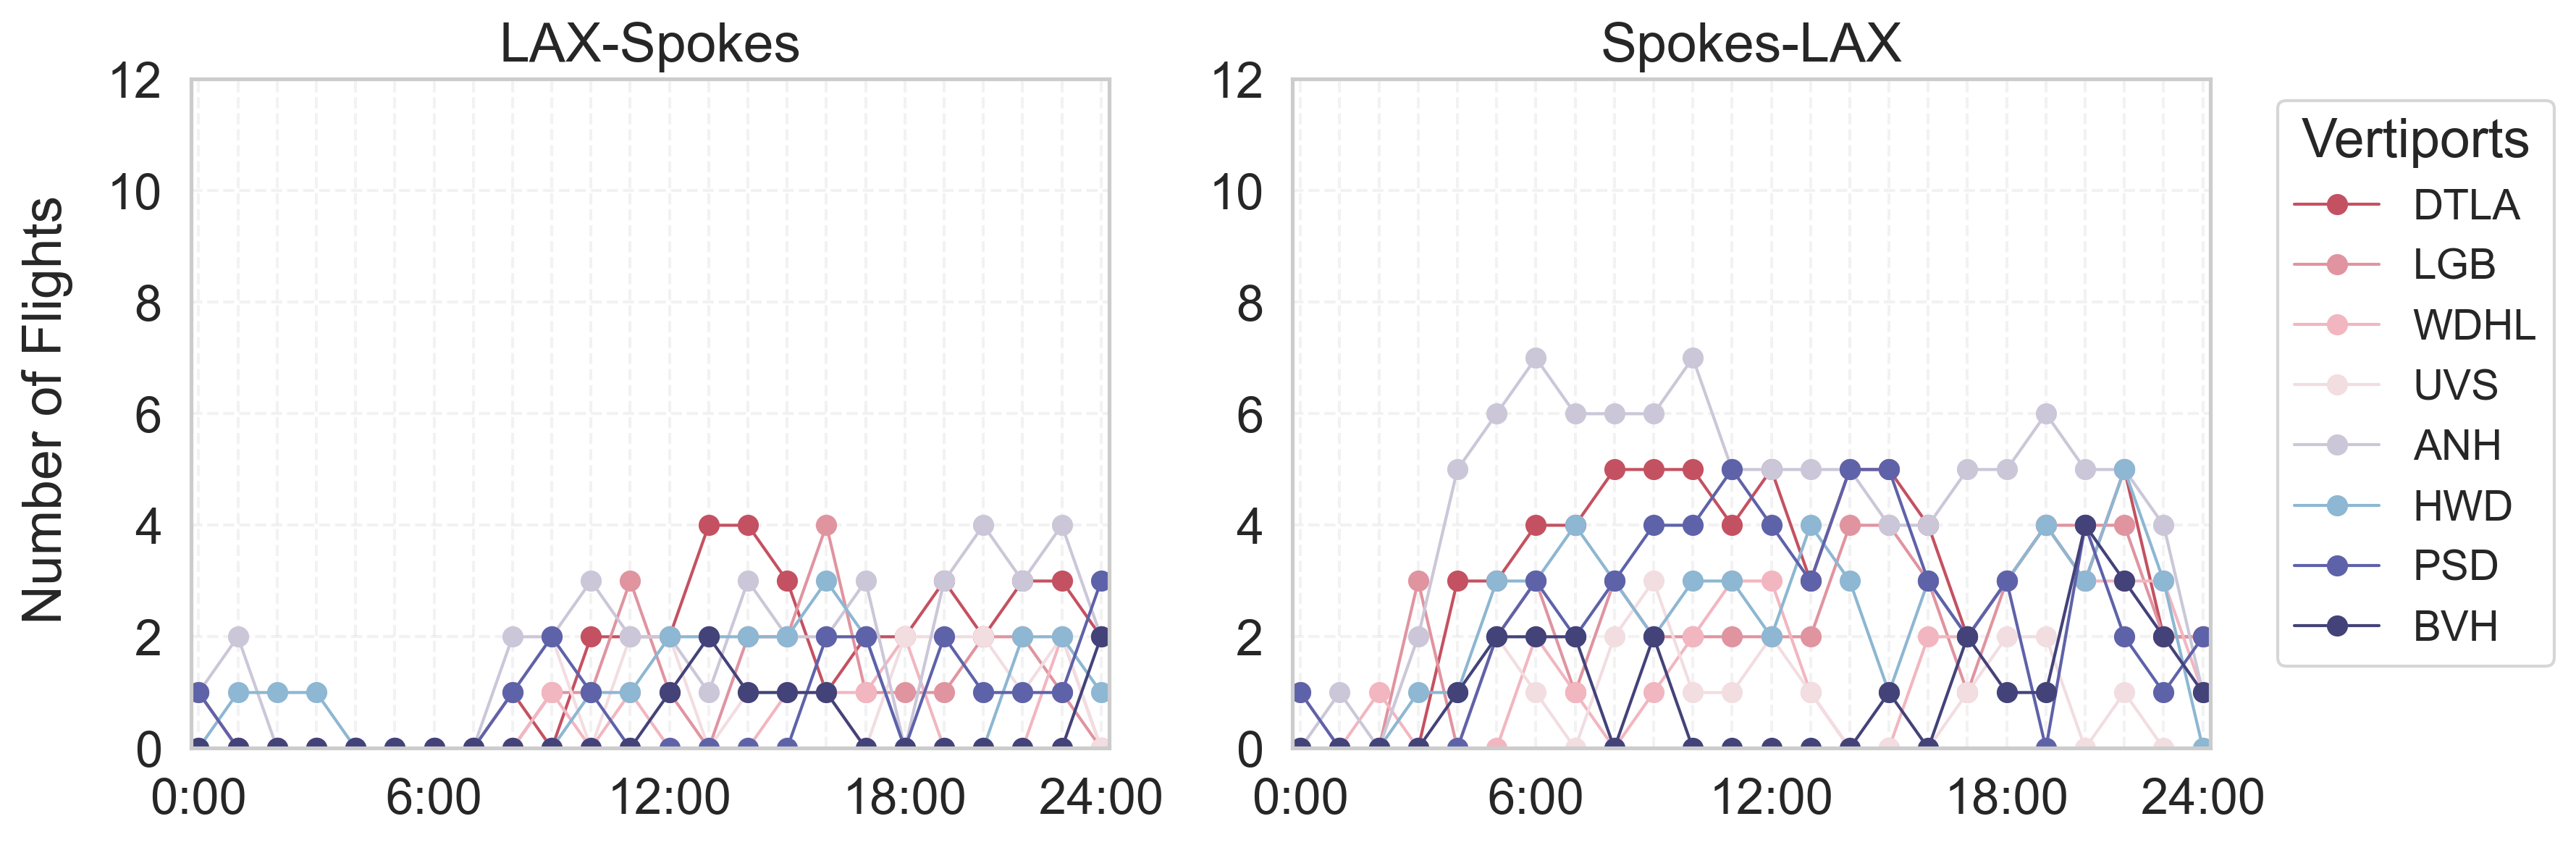

In [14]:
network.plot_flight(ylim=(0, 12));

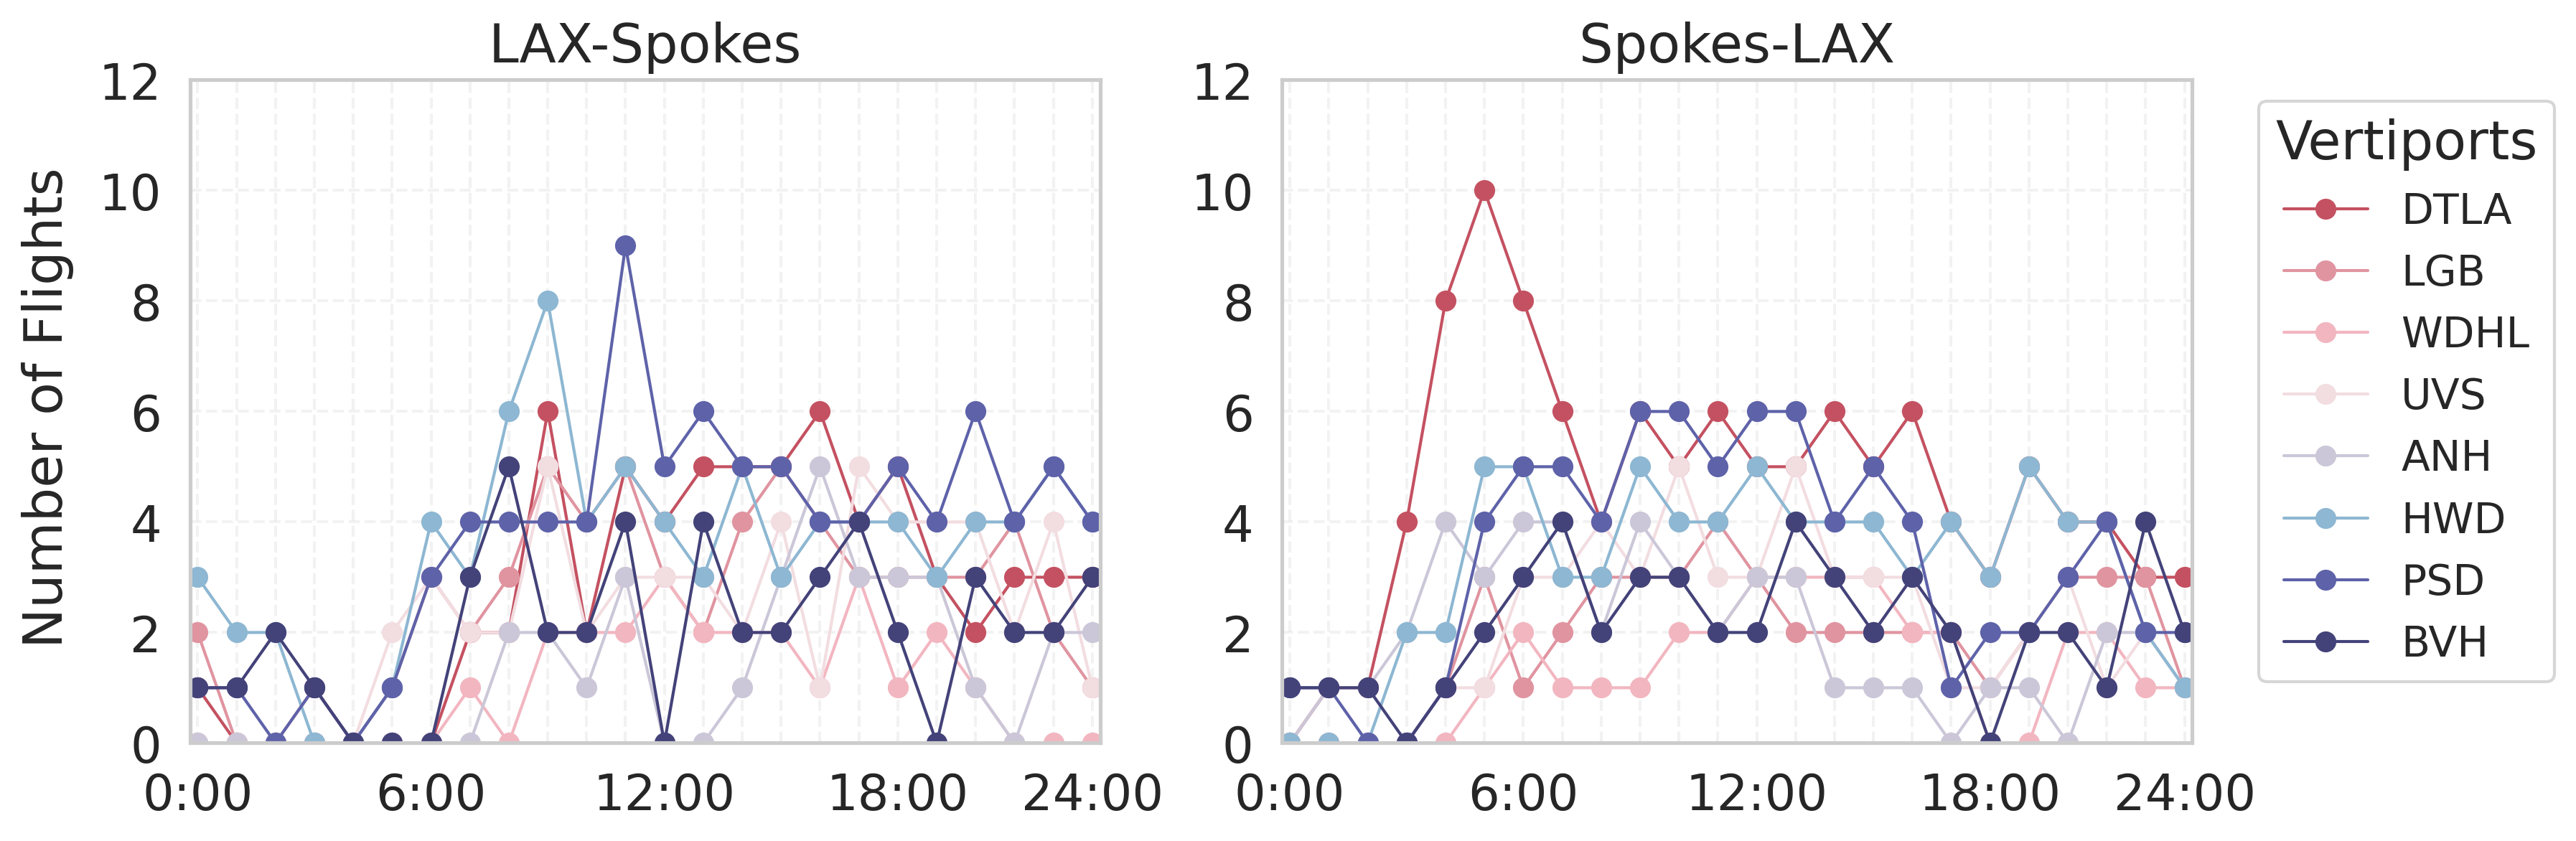

In [ ]:
# network.plot_flight(ylim=(0, 12));

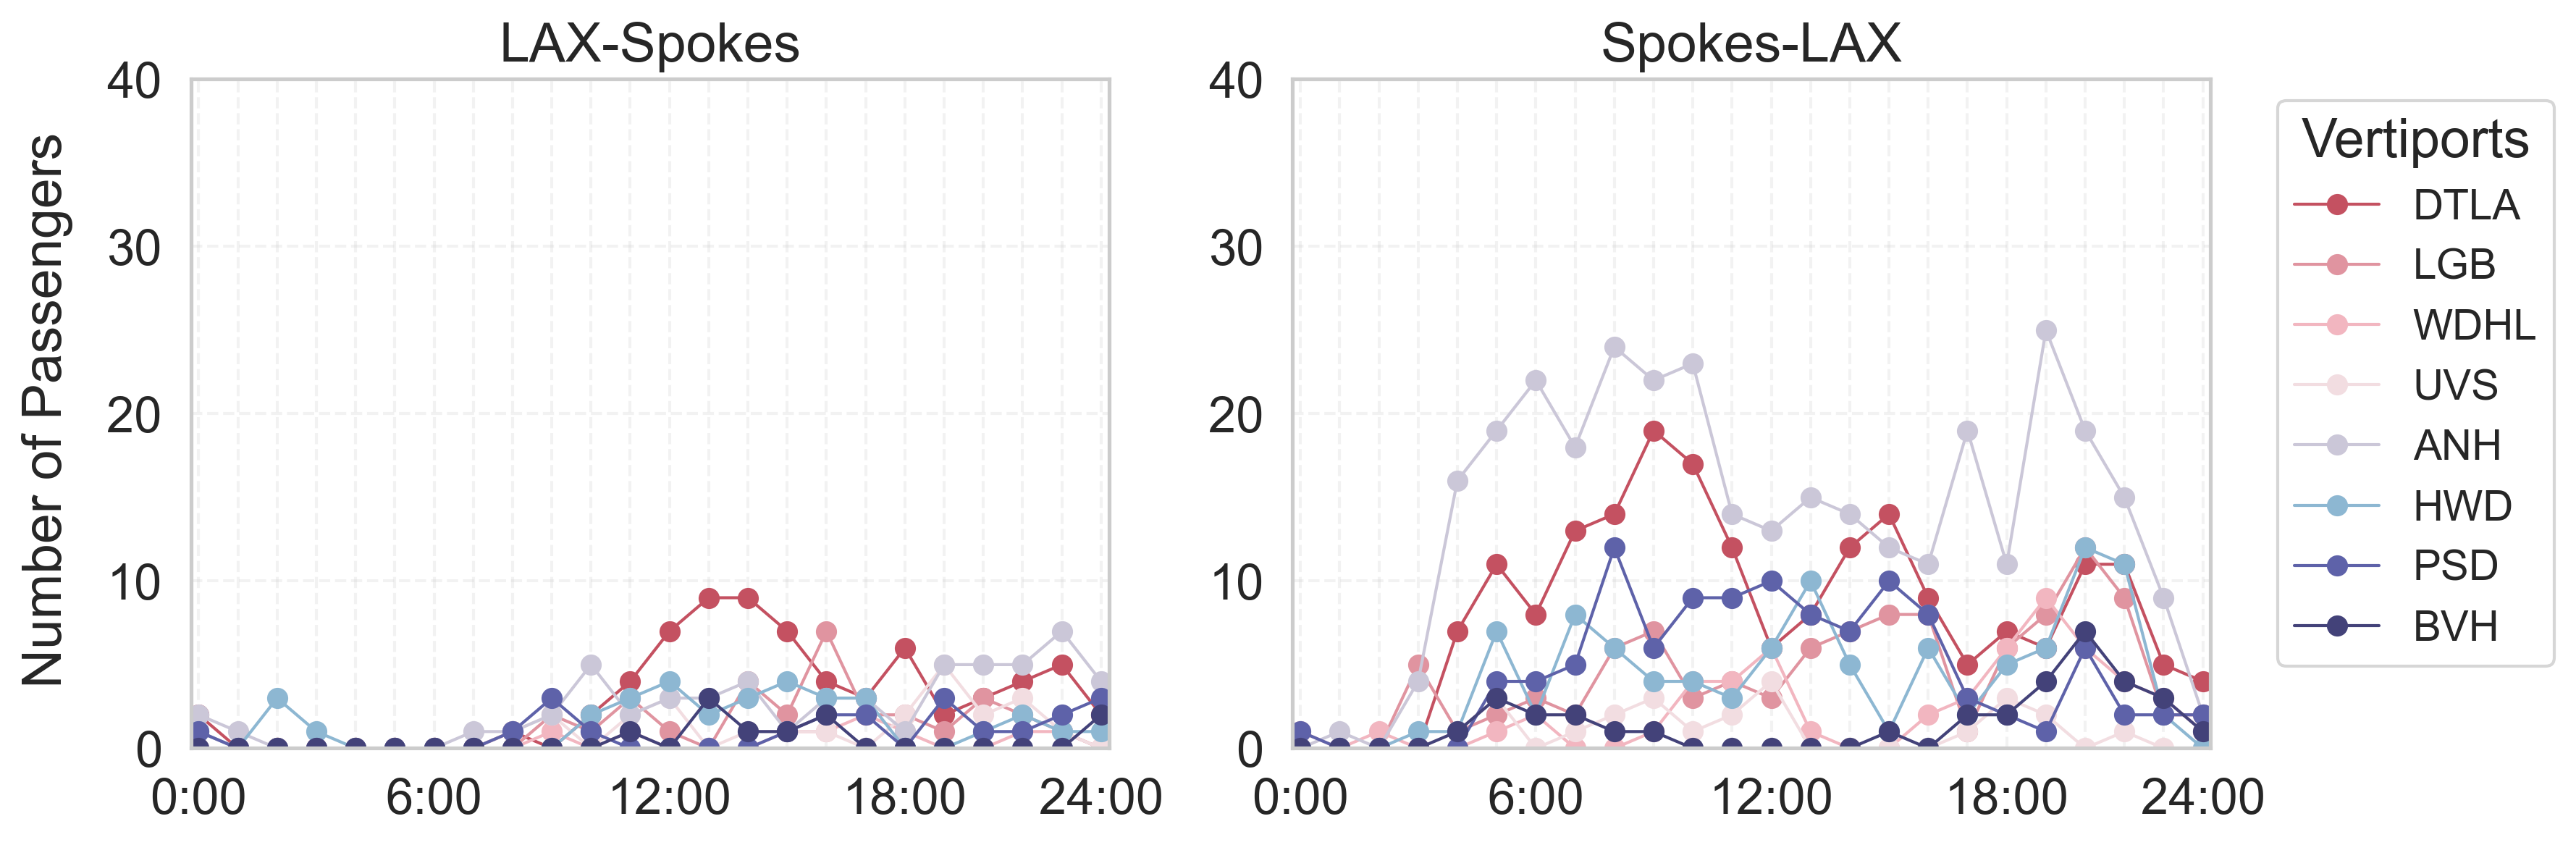

In [15]:
network.plot_pax(ylim=(0, 40));

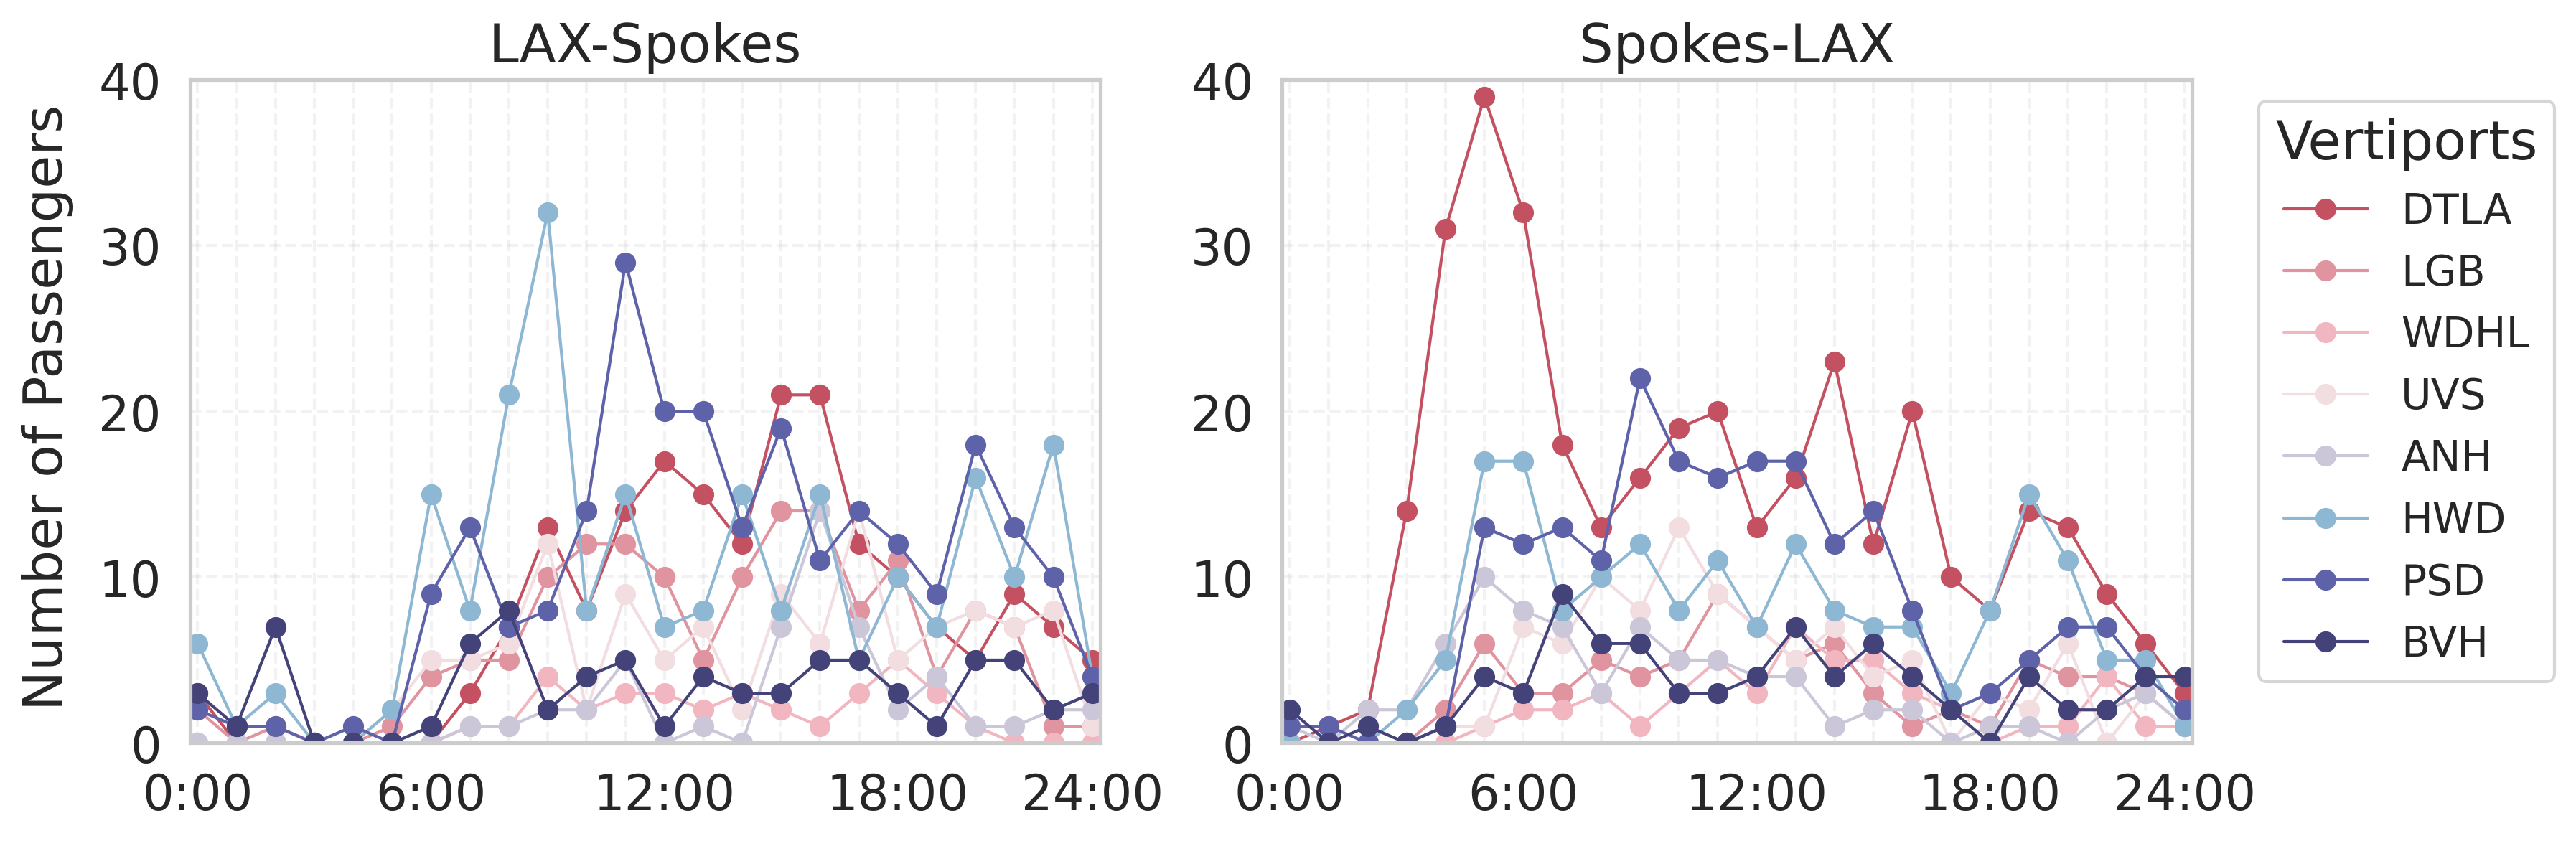

In [ ]:
# network.plot_pax(ylim=(0, 40));

### Optimization models

#### Validate fleet size with IP

In [141]:
from uam_system_model.FleetSizeOp import FleetSizeOptimizer
from uam_system_model.utils.FleetSizeOpSummary import FleetSizeOpSummary

ip = FleetSizeOptimizer(network)
network_fleet_size = []
for i in range(1, 9):
    fleetsize, policy = ip.optimize(vertiport_index=i,
                                    verbose=True, 
                                    optimality_gap=0.05, 
                                    n_threads=24)
    network_fleet_size.append(fleetsize)
    policy.to_csv(f"output/ECO_IP_WAIT10_FARE3/ip_policy_{i}.csv")
                                    

Set parameter Username
Academic license - for non-commercial use only - expires 2025-10-30
Set parameter Threads to value 24
Set parameter MIPGap to value 0.05
Set parameter FeasibilityTol to value 1e-05
Set parameter TimeLimit to value 1800
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel(R) Xeon(R) Gold 6326 CPU @ 2.90GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 32 physical cores, 64 logical processors, using up to 24 threads

Optimize a model with 21700 rows, 349272 columns and 685852 nonzeros
Model fingerprint: 0xf1d17077
Variable types: 0 continuous, 349272 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-05, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+00]
Presolve removed 2447 rows and 32213 columns
Presolve time: 1.95s
Presolved: 19253 rows, 317059 columns, 637803 nonzeros
Variable types: 0 continuous, 317059 integer (1 binary)
Deterministic concurrent LP optimi

In [143]:
sum(network_fleet_size)

31

#### total number of seats x P(OD passenger) x P(OD) x P(TNC) x P(Mode Share)

#### P(OD) = 77.5M / 102243130.0 = 0.7580

#### Run IP

In [14]:
from uam_system_model.FleetSizeOp import FleetSizeOptimizer
from uam_system_model.utils.FleetSizeOpSummary import FleetSizeOpSummary

In [15]:
fs = []
for i in range(1,9):
    file = pd.read_csv(f"output/ECO_IP_WAIT10_FARE3/ip_policy_{i}.csv")
    summary = FleetSizeOpSummary(network, file)
    output = summary.get_summary_statistics()
    fs.append(output['fleet_size'])

In [16]:
np.array(fs).sum()
# summary.plot_aircraft_state()

31

### Analytics

In [11]:
from uam_system_model.utils.FleetOpVRPSummary import FleetOpVRPSummary

In [12]:
path = 'output/ECO_WAIT10_FARE3/'
list_of_files = os.listdir(path)
list_of_files = [file for file in list_of_files if not file.endswith('clustering.csv')]

policy_0 = pd.read_csv(path + list_of_files[0])
summary_0 = FleetOpVRPSummary(network, policy_0)
statistics_0 = summary_0.get_summary_statistics()
df = pd.DataFrame([statistics_0])

for file in tqdm(list_of_files[1:]):
    policy = pd.read_csv(path + file)
    summary = FleetOpVRPSummary(network, policy)
    statistics = summary.get_summary_statistics()
    df = pd.concat([df, pd.DataFrame([statistics])], ignore_index=True)

fs_idxmax = df.groupby("fleet_size")['number_of_revenue_flights'].idxmax()
df_max = df.loc[fs_idxmax].sort_values(by='fleet_size')
df_max = df_max[df_max['fleet_size']<=34]

100%|██████████| 16/16 [00:21<00:00,  1.36s/it]


#### Making fleet sizing decision


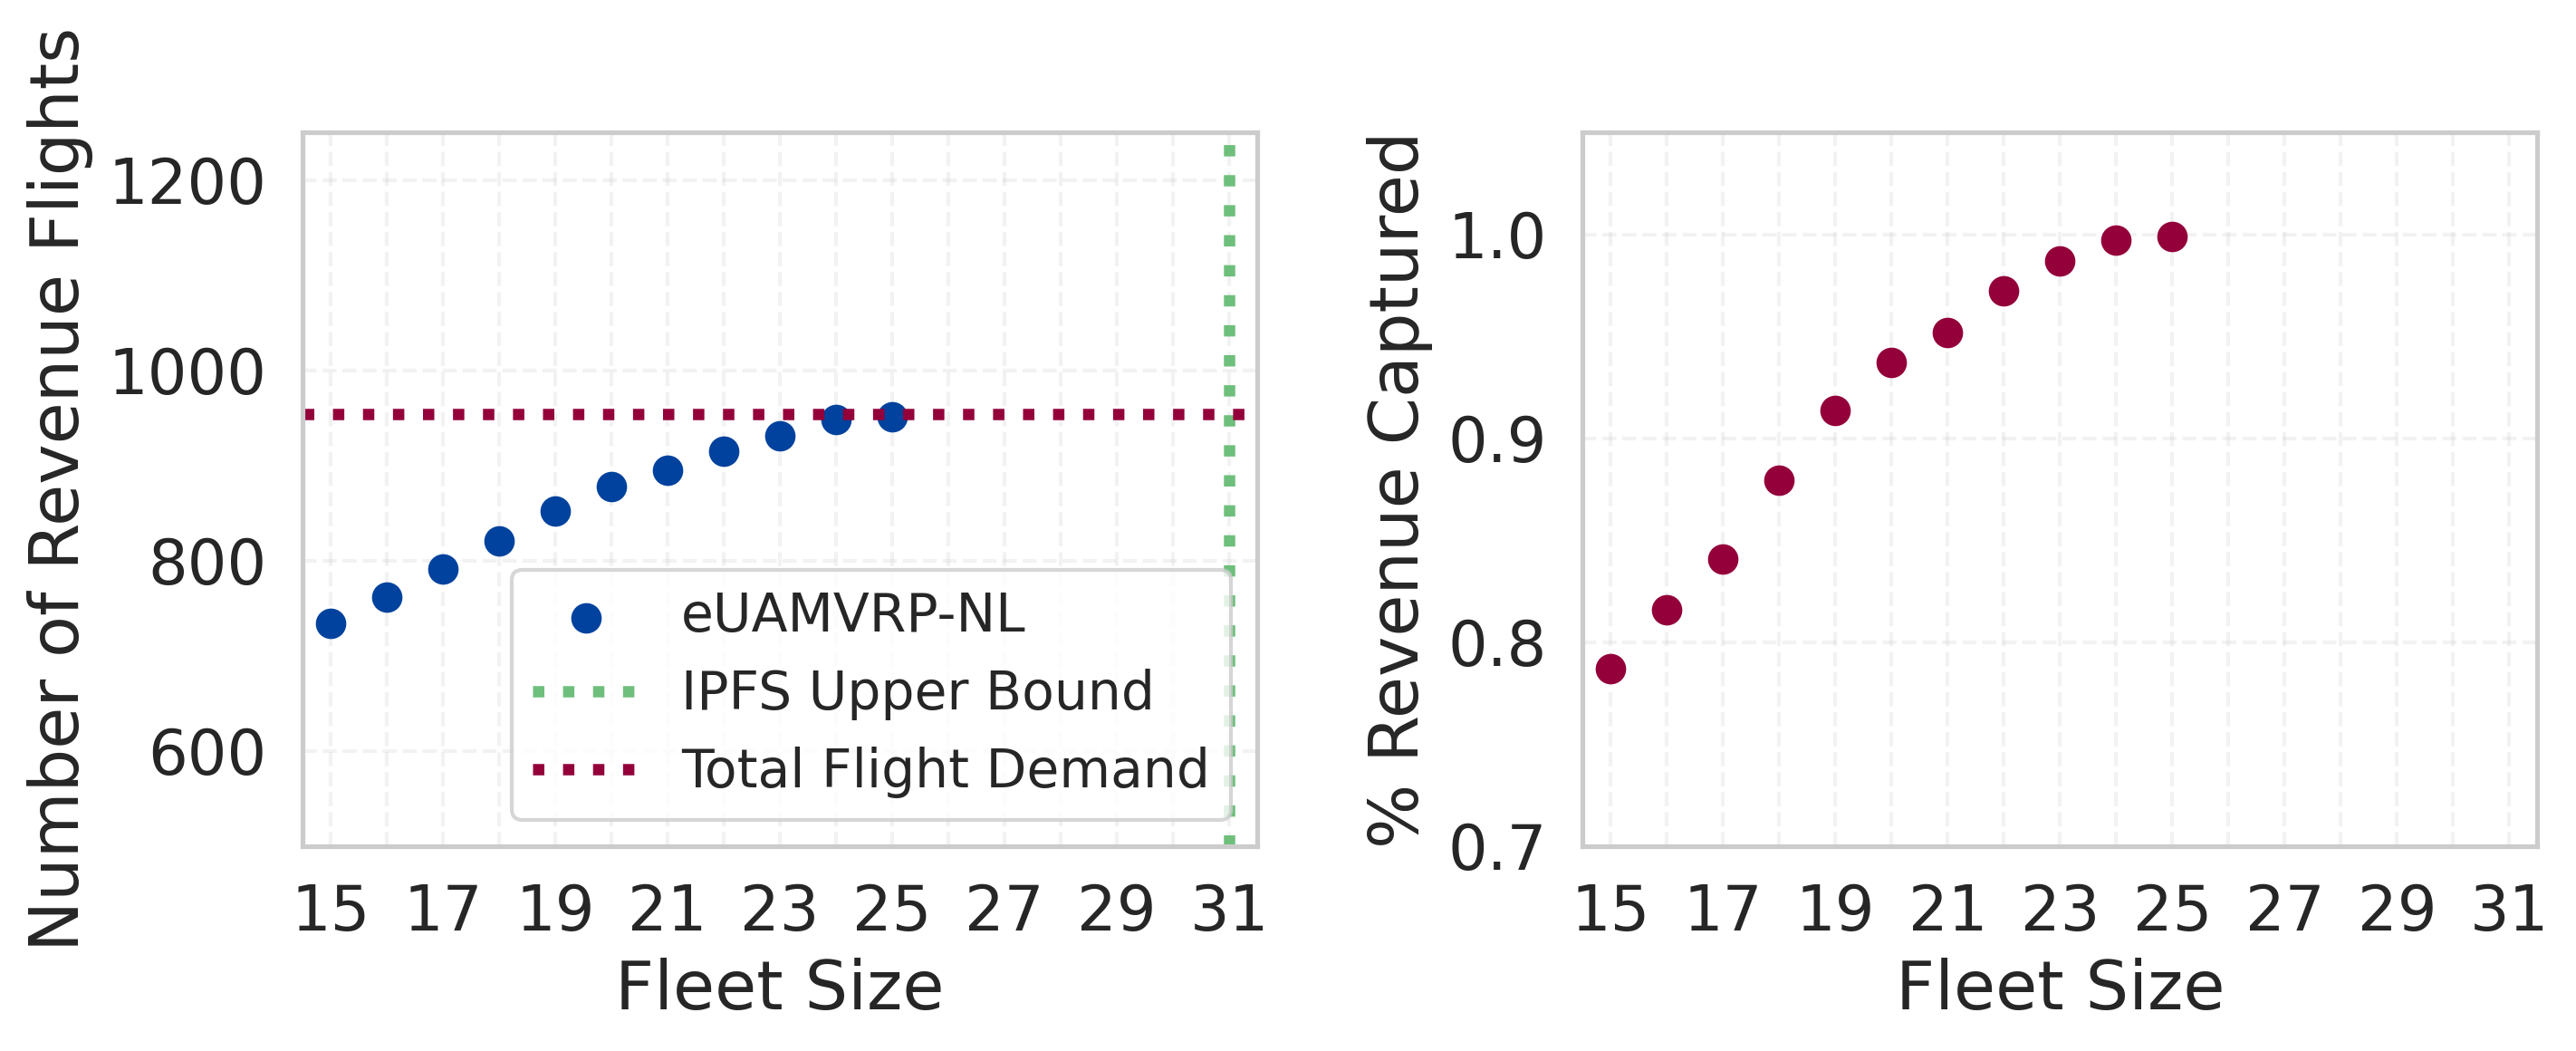

In [34]:
fig, ax = plt.subplots(figsize=(10, 4), ncols=2, dpi=300)
ax[0].scatter(df_max['fleet_size'], df_max['number_of_revenue_flights'], color=color[1], 
              s=50, label="eUAMVRP-NL")
ax[1].scatter(df_max['fleet_size'], df_max['total_revenue']/network.schedule['revenue'].sum(), color=color[0], s=50)

for i in range(2):
    ax[i].set(xlim=(14.5, 31.5), xticks=np.arange(15, 33, 2),
              xlabel="Fleet Size")
    ax[i].xaxis.set_minor_locator(MultipleLocator(1))
    ax[i].grid(True, alpha=0.25, linestyle='--', which='both')
ax[0].set(ylim=(500, 1250), ylabel="Number of Revenue Flights")
ax[1].set(ylim=(0.7, 1.05), ylabel="% Revenue Captured")
ax[0].axvline(x=31, color=color[3], linestyle=':', linewidth=3, label='IPFS Upper Bound')
ax[0].axhline(y=network.schedule.shape[0], color=color[0], linestyle=':', linewidth=3, label='Total Flight Demand')
ax[0].legend(loc='lower right')
plt.tight_layout()


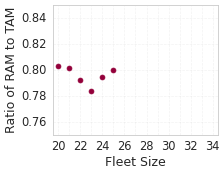

In [35]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=50)
ax.scatter(df_max['fleet_size'],  df_max['RAM']/ df_max['TAM'], color=color[0], s=50)
ax.set(xlim=(19.5, 34.5), ylim=(0.75, 0.85), xticks=np.arange(20, 36, 2),
            xlabel="Fleet Size", ylabel="Ratio of RAM to TAM")
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.grid(True, alpha=0.25, linestyle='--', which='both')
plt.tight_layout()


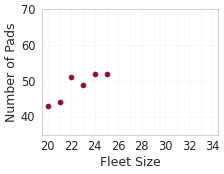

In [36]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=50)
ax.scatter(df_max['fleet_size'], df_max['total_pads'], color=color[0], s=50)
ax.set(xlim=(19.5, 34.5), ylim=(35, 70), xticks=np.arange(20, 36, 2),
            xlabel="Fleet Size", ylabel="Number of Pads")
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.grid(True, alpha=0.25, linestyle='--', which='both')
plt.tight_layout()

#### Infrastructure sizing

In [41]:
path = 'output/ECO_WAIT10_FARE3/'
policy_0 = pd.read_csv(path + "25_4_4_4.csv")
summary_0 = FleetOpVRPSummary(network, policy_0)
statistics_0 = summary_0.get_summary_statistics()
df = pd.DataFrame([statistics_0])

required_pads = {}
for row in df['pads_at_vertiport']:
    for key, value in row.items():
        # Keep the max value seen so far for each key
        if key not in required_pads:
            required_pads[key] = value
        else:
            required_pads[key] = max(required_pads[key], value)
required_pads

{'LAX': 13,
 'DTLA': 6,
 'LGB': 4,
 'WDHL': 4,
 'UVS': 6,
 'ANH': 4,
 'HWD': 6,
 'PSD': 5,
 'BVH': 4}

In [42]:
statistics_0

{'fleet_size': 25,
 'total_pads': 52,
 'pads_at_vertiport': {'LAX': 13,
  'DTLA': 6,
  'LGB': 4,
  'WDHL': 4,
  'UVS': 6,
  'ANH': 4,
  'HWD': 6,
  'PSD': 5,
  'BVH': 4},
 'max_takeoff_per_hour': {'LAX': 45,
  'DTLA': 19,
  'LGB': 6,
  'WDHL': 6,
  'UVS': 9,
  'ANH': 9,
  'HWD': 9,
  'PSD': 11,
  'BVH': 9},
 'number_of_aircraft_hours': 217.42,
 'number_of_flights': 1178,
 'number_of_revenue_flights': 951,
 'number_of_repositioning_flights': 227,
 'percentage_repositioning_flights': 0.1927,
 'energy_consumption_kWh': 19890.5,
 'TAM': 16674.19,
 'RAM': 13335.94,
 'total_revenue': 89187.86705650609,
 'average_load_factor': 0.5818}

#### Patterns in opex and revenue

In [44]:
path = 'output/ECO_WAIT10_FARE3/'
policy_0 = pd.read_csv(path + "25_4_4_4.csv")
summary_0 = FleetOpVRPSummary(network, policy_0)
statistics_0 = summary_0.get_summary_statistics()

In [45]:
rev = {i:0 for i in vertiports if i != "LAX"}
rev_hours = {i:0 for i in vertiports if i != "LAX"}
repo_hours = {i:0 for i in vertiports if i != "LAX"}
for idx, row in policy_0.iterrows():
    sequence = row['tour_sequence'].split("-")
    for i in range(len(sequence)-1):
        origin = sequence[i]
        destination = sequence[i+1]
        if origin == "LAX":
            market = destination
        elif destination == "LAX":
            market = origin
        
        rev[market] += row["tour_revenue"]/ row["tour_length"]
        rev_hours[market] += row["duration"] / row["tour_length"]

    if (row['next_origin'] != 0) & (row['next_origin'] != 999):
        repo_hours[network.vertiport_dict_inv[row['next_origin']]] += row['repo_flight_duration']


In [46]:
joined = pd.DataFrame({
    'revenue': rev,
    'revenue_hours': rev_hours,
    'repo_hours': repo_hours
}).reset_index()
joined['unit_rev_per_aircraft_hour'] = joined['revenue'] / (joined['revenue_hours'] + joined['repo_hours']) * 60

num_pax_per_market = network.schedule.groupby(["od"])['num_pax'].sum().reset_index()
num_pax_per_market['market'] = num_pax_per_market['od'].apply(lambda x: x if x.split("_")[0] == "LAX" else x.split("_")[1] + "_" + x.split("_")[0])
num_pax_per_market['market'] = num_pax_per_market['market'].apply(lambda x: x.split("_")[1])
num_pax_per_market = num_pax_per_market.groupby("market")['num_pax'].sum().reset_index()
joined = pd.merge(num_pax_per_market, joined, left_on='market', right_on='index')

num_flight_per_market = network.schedule.groupby(["od"]).count().reset_index()
num_flight_per_market['market'] = num_flight_per_market['od'].apply(lambda x: x if x.split("_")[0] == "LAX" else x.split("_")[1] + "_" + x.split("_")[0])
num_flight_per_market['market'] = num_flight_per_market['market'].apply(lambda x: x.split("_")[1])
num_flight_per_market = num_flight_per_market.groupby("market")['revenue'].sum().reset_index()
num_flight_per_market = num_flight_per_market.rename(columns={'revenue': 'num_flight'})
joined = pd.merge(num_flight_per_market, joined, left_on='market', right_on='index').drop(columns=['market_x', 'market_y'])

In [47]:
joined['load_factor'] = joined['num_pax'] / joined['num_flight'] /4
joined['repo_hour_percentage'] = joined['repo_hours'] / (joined['repo_hours'] + joined['revenue_hours'])

In [48]:
joined

,num_flight,num_pax,index,revenue,revenue_hours,repo_hours,unit_rev_per_aircraft_hour,load_factor,repo_hour_percentage
0,77,129,ANH,11011.631059,1100.0,325,463.647624,0.418831,0.228070
1,98,158,BVH,4518.180651,962.5,250,223.580073,0.403061,0.206186
2,178,541,DTLA,16997.620732,1827.5,580,423.616716,0.759831,0.240914
3,161,413,HWD,14043.992221,1637.5,165,467.483791,0.641304,0.091540
4,109,224,LGB,11091.377040,1305.0,95,475.344730,0.513761,0.067857
5,168,453,PSD,17199.629896,1700.0,180,548.924358,0.674107,0.095745
6,107,218,UVS,9410.595181,1095.0,240,422.948098,0.509346,0.179775
7,56,84,WDHL,4914.840277,772.5,145,321.406449,0.375,0.158038


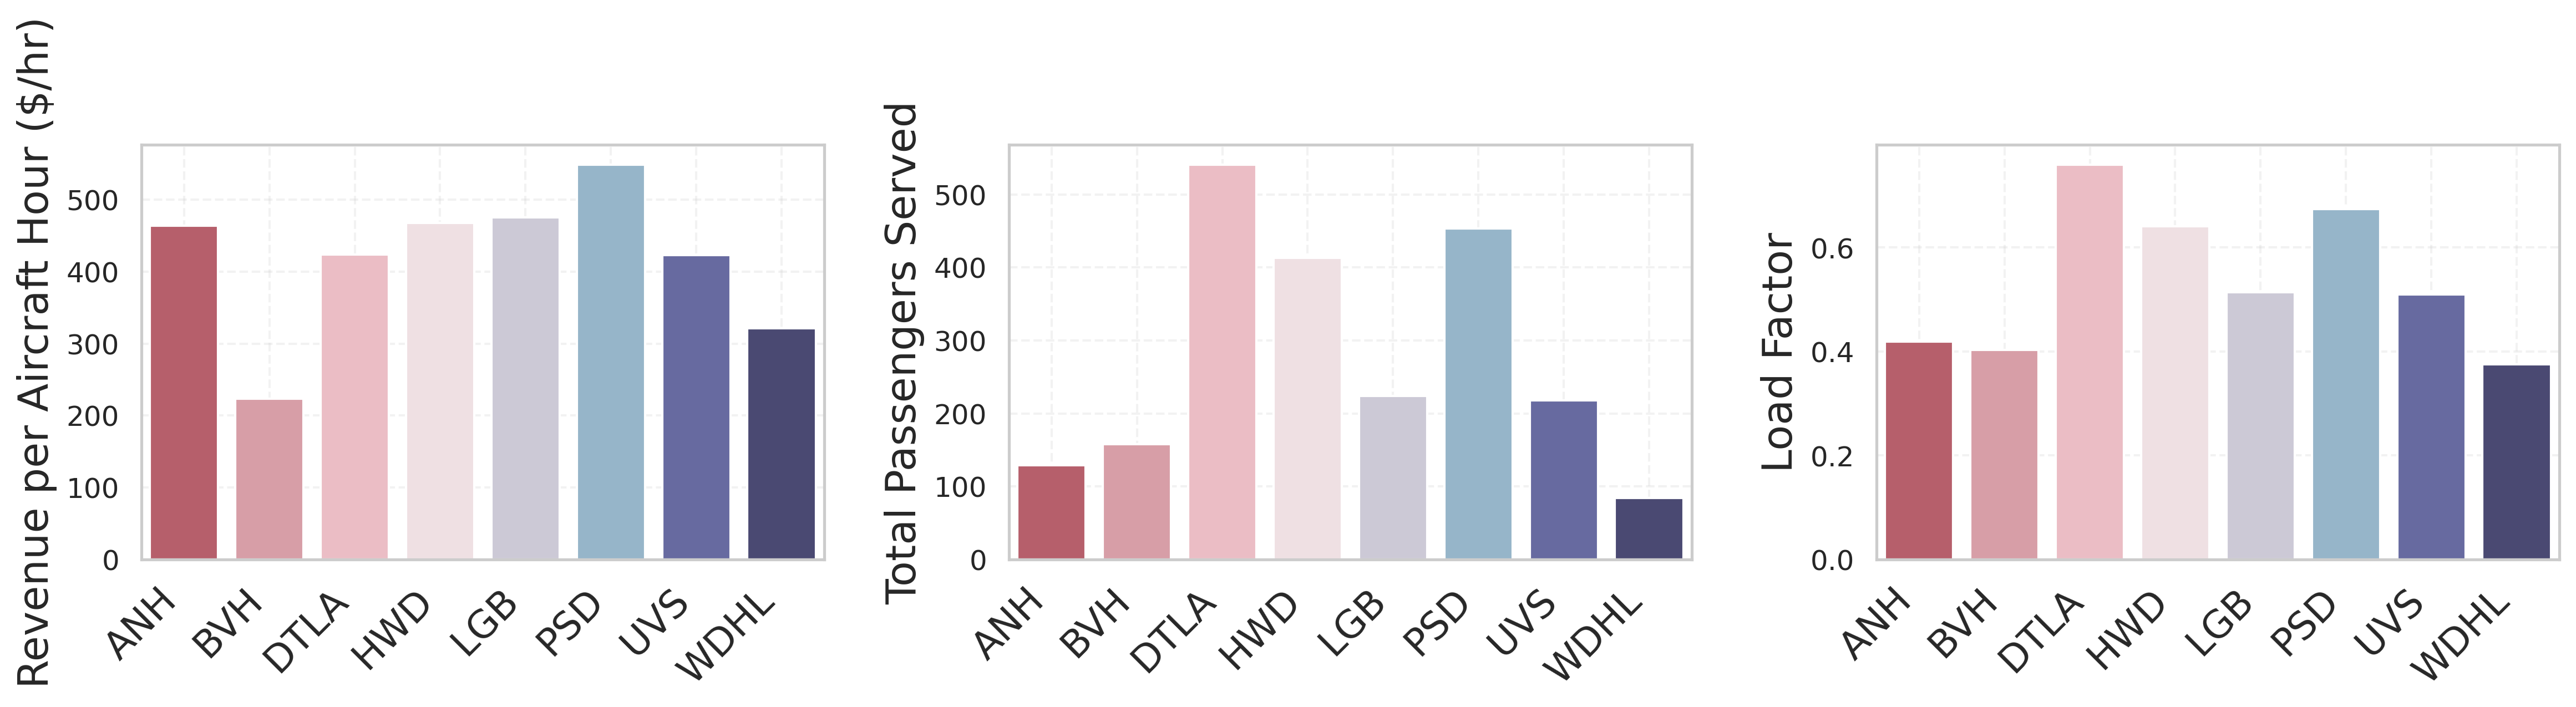

In [49]:
fig, ax = plt.subplots(figsize=(16, 4), dpi=300, ncols=3)
sns.barplot(data=joined, x='index', y='unit_rev_per_aircraft_hour', ax=ax[0], palette=custom_colors)
sns.barplot(data=joined, x='index', y='num_pax', ax=ax[1], palette=custom_colors)
sns.barplot(data=joined, x='index', y='load_factor', ax=ax[2], palette=custom_colors)
ax[0].set_ylabel("Revenue per Aircraft Hour ($/hr)")
ax[1].set_ylabel("Total Passengers Served")
ax[2].set_ylabel("Load Factor")
for i in range(3):
    ax[i].tick_params(axis='y', labelsize=12)
    ax[i].set_xlabel("")
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')
    ax[i].grid(True, alpha=0.25, linestyle='--', which='both')


plt.tight_layout()


#### cost-revenue analysis

In [50]:
import importlib
import uam_system_model.financial_analysis.cost
importlib.reload(uam_system_model.financial_analysis.cost)
from uam_system_model.financial_analysis.cost import CostAnalyzer


In [52]:
path = 'output/ECO_WAIT10_FARE3/'

policy_0 = pd.read_csv(path + "25_4_4_4.csv")
summary_0 = FleetOpVRPSummary(network, policy_0)
statistics_0 = summary_0.get_summary_statistics()
df = pd.DataFrame([statistics_0])

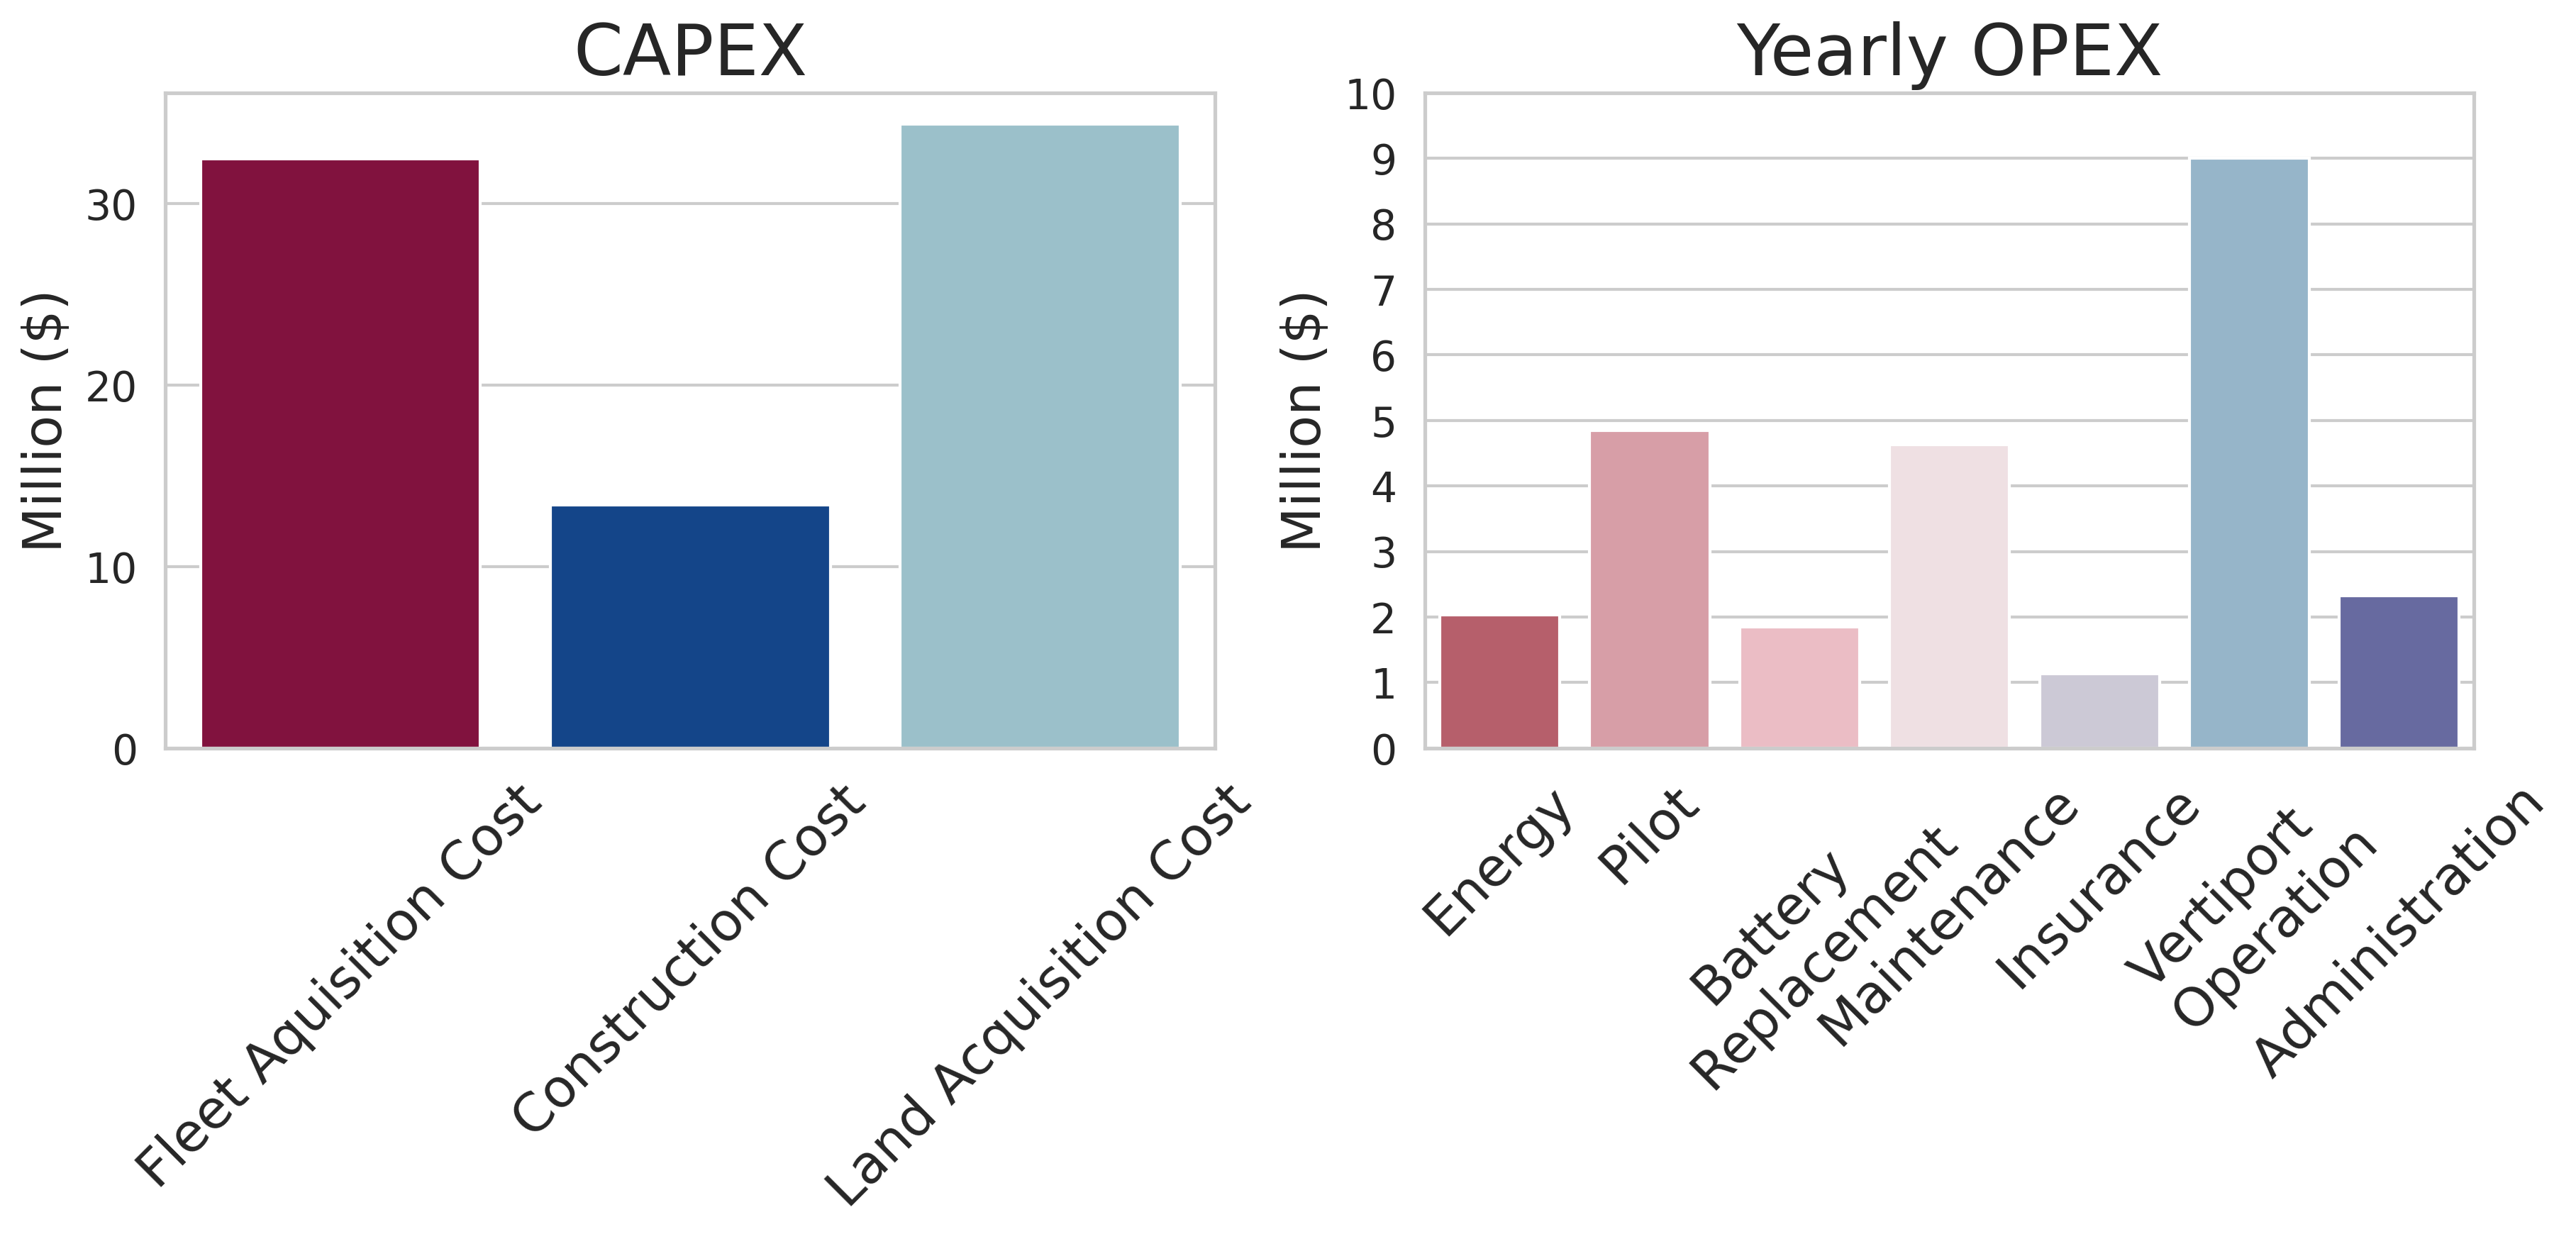

In [53]:
c = CostAnalyzer("../UAM-System-Model/uam_system_model/data/config/financial_analysis_params.json")
capex, opex, rev, prof = c.analyze(df_max[df_max['fleet_size']==25].reset_index(drop=True))
c.plot();

#### Financial projection

ROI (undiscounted) ............ : -0.28
NPV @ 8% ............. : $-22,595,775
IRR ........................... : 3.03%
Not recovered


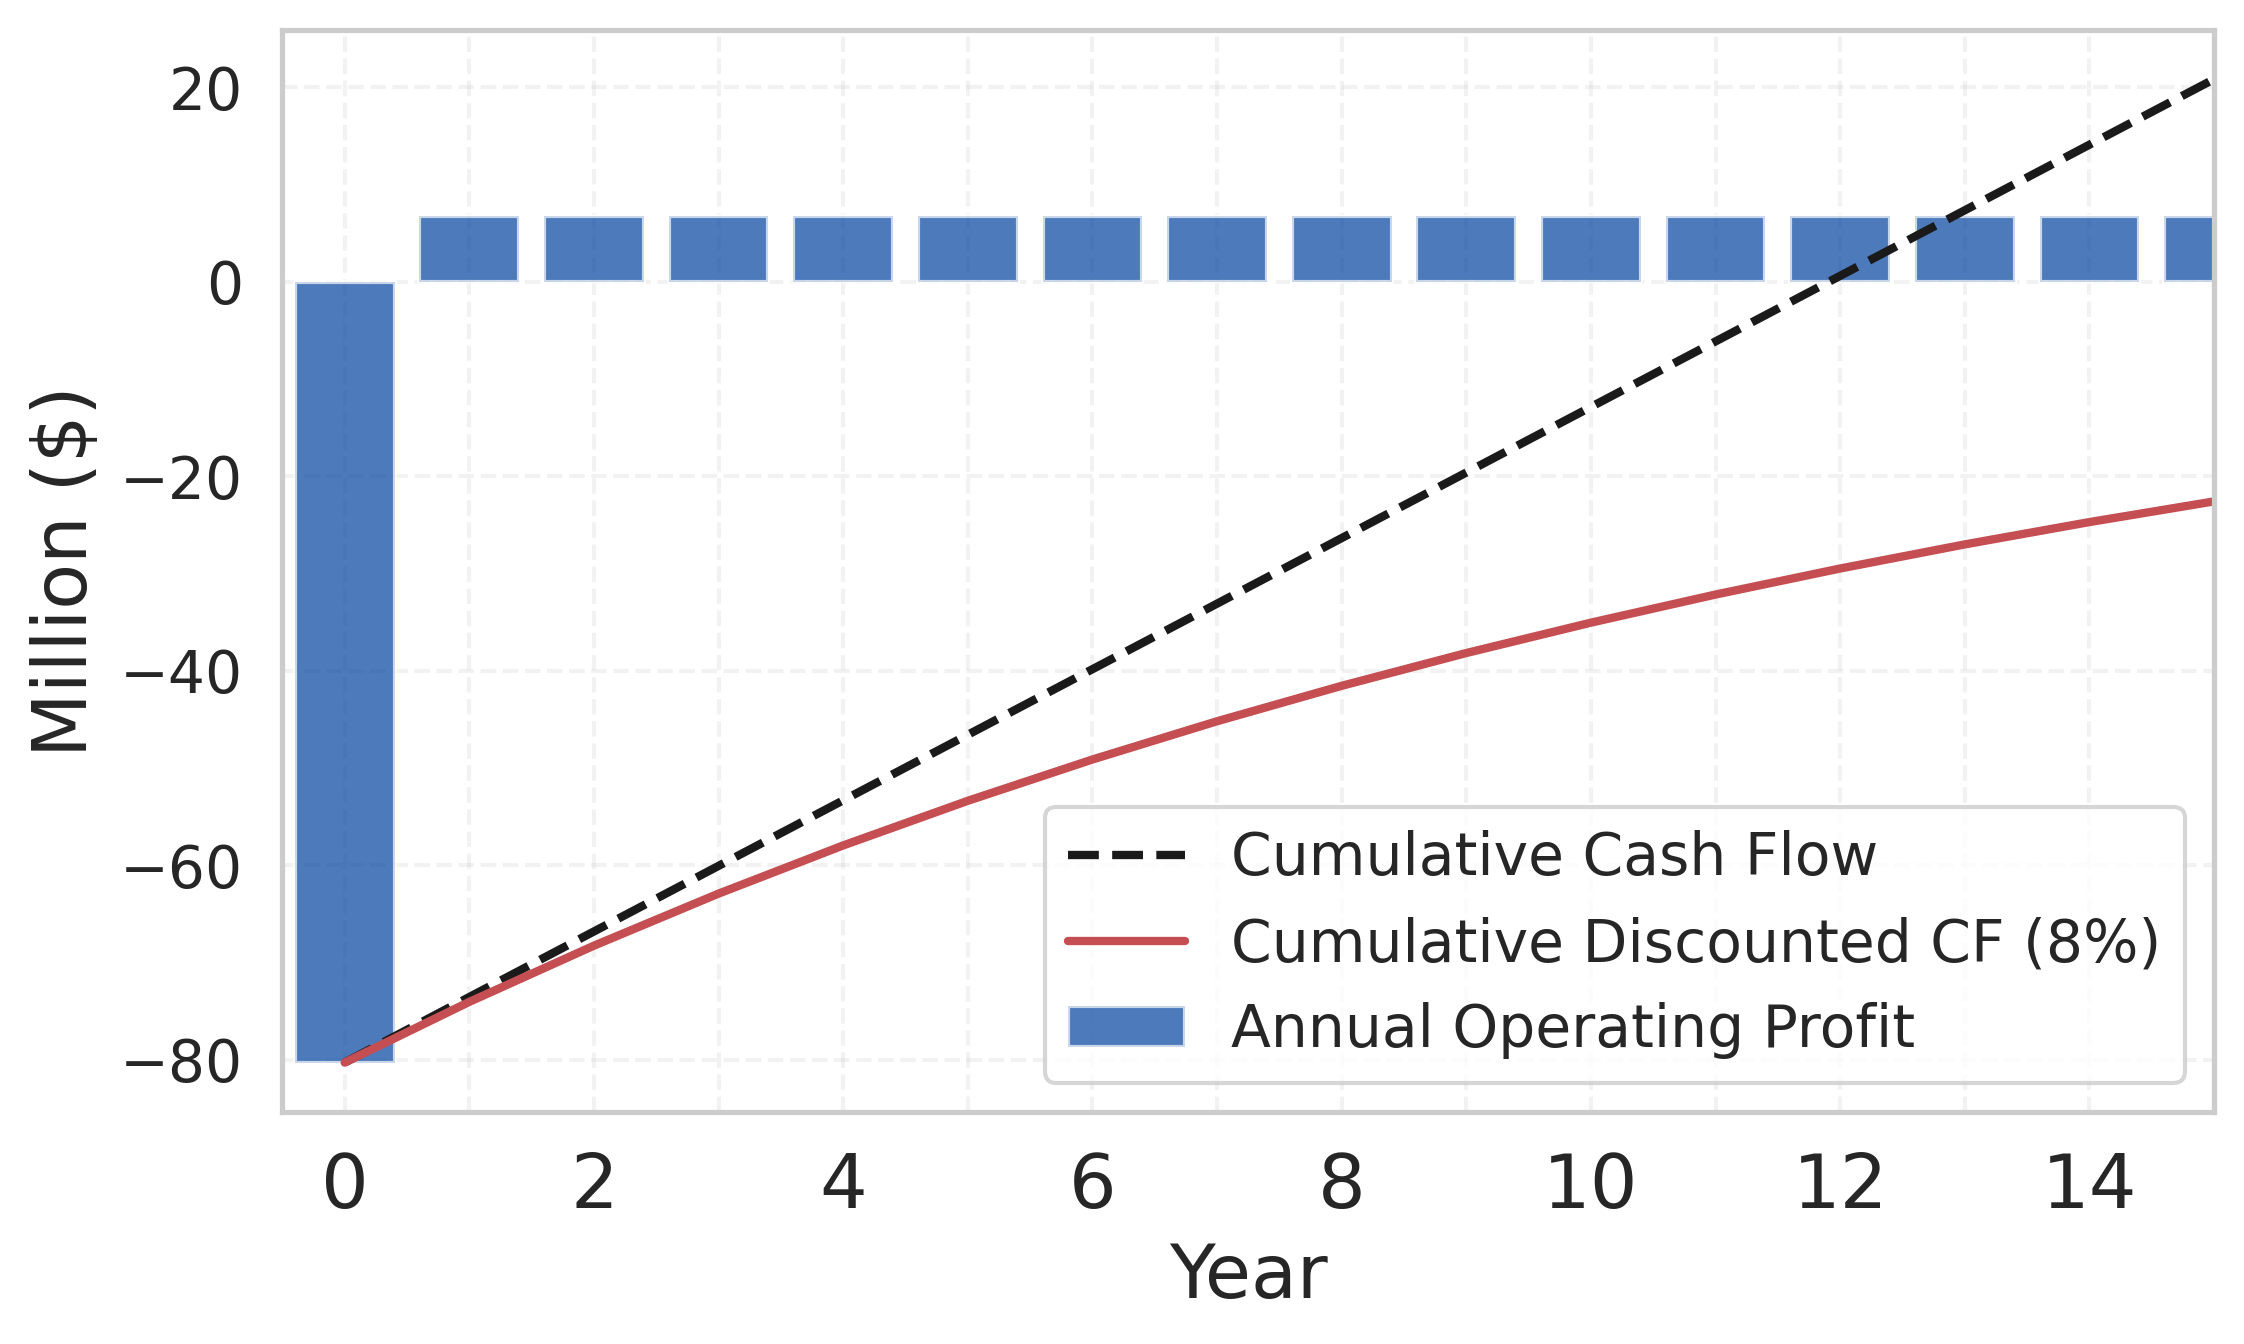

In [54]:
fig, ax, ROI, NPV, IRR, payback_year = c.projection()